# HGP concordance inspection vs PINN

This short notebook inspects the finished hierarchical GP-style concordance product and compares it with the existing PINN concordance fields.

**What this checks**

1. HGP run metadata, holdout calibration and per-band field amplitudes from the JSON sidecar.
2. HGP mean field vs the PINN head-residual field on a common sky grid.
3. HGP posterior uncertainty and coverage maps.
4. The HGP common / Rubin-or-NISP / band-specific decomposition.

The grids are not compared pixel-by-pixel directly: the HGP product is written on a 5 arcsec mesh, while the saved PINN products are on a 1 arcsec mesh. We sample the PINN field at the HGP sky coordinates before comparing vectors.

**Important caveat.** The default comparison below is now apples-to-apples in source catalogue: HGP and PINN both use the CenterNet anchor cache. HGP fits `head_resid`; the default PINN head-residual product was refit from the same `anchors_centernet.npz` cache for this notebook. Differences between HGP and PINN are therefore mainly model/prior differences, with a small remaining difference from each fitter's clipping/weighting choices.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from scipy.ndimage import map_coordinates

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 180,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

ROOT = Path.cwd().parent if Path.cwd().name == 'io' else Path.cwd()
CKPT = ROOT / 'models/checkpoints/latent_position_v8_no_psf'

HGP_FITS = CKPT / 'concordance_hgp_head_resid_richer.fits'
HGP_JSON = CKPT / 'concordance_hgp_head_resid_richer.fits.json'
PINN_HEAD_FITS = CKPT / 'concordance_pinn_centernet_head_resid.fits'
PINN_RAW_FITS = CKPT / 'concordance_pinn_centernet_raw.fits'

BANDS = ['U', 'G', 'R', 'I', 'Z', 'Y', 'NISP_Y', 'NISP_J', 'NISP_H']
BAND_LABEL = {
    'U': 'u', 'G': 'g', 'R': 'r', 'I': 'i', 'Z': 'z', 'Y': 'y',
    'NISP_Y': 'NISP Y', 'NISP_J': 'NISP J', 'NISP_H': 'NISP H',
}

# COVERAGE in these FITS files is distance to the nearest anchor, in arcsec.
# Use a support mask for quantitative comparisons so edge extrapolation does
# not dominate field RMS. Tune these thresholds if you want a stricter mask.
MAX_NEAREST_ANCHOR_ARCSEC = 30.0
MAX_HGP_STD_RADIAL_MAS = 10.0

for path in [HGP_FITS, HGP_JSON, PINN_HEAD_FITS, PINN_RAW_FITS]:
    if not path.exists():
        raise FileNotFoundError(path)

print('HGP:', HGP_FITS.relative_to(ROOT))
print('PINN head residual:', PINN_HEAD_FITS.relative_to(ROOT))
print('PINN raw:', PINN_RAW_FITS.relative_to(ROOT))

HGP: models/checkpoints/latent_position_v8_no_psf/concordance_hgp_head_resid_richer.fits
PINN head residual: models/checkpoints/latent_position_v8_no_psf/concordance_pinn_centernet_head_resid.fits
PINN raw: models/checkpoints/latent_position_v8_no_psf/concordance_pinn_centernet_raw.fits


In [2]:
def product_header_summary(path, band='I'):
    with fits.open(path, memmap=True) as hdul:
        primary = hdul[0].header
        h = hdul[f'{band}.DRA'].header
        return {
            'product': path.name,
            'method_primary': primary.get('METHOD', ''),
            'method_band': h.get('METHOD', ''),
            'anchors': primary.get('ANCHORS', ''),
            'offset_kind': primary.get('OFFKIND', ''),
            'n_anchor_primary': primary.get('NANCHOR', np.nan),
            'n_anchor_band': h.get('NANCHORS', h.get('NSRC', np.nan)),
            'dstep_arcsec': h.get('DSTEP', primary.get('DSTEP', np.nan)),
            'shape': (h['NAXIS2'], h['NAXIS1']),
            'ra0': h.get('RA0', h.get('CRVAL1', np.nan)),
            'dec0': h.get('DEC0', h.get('CRVAL2', np.nan)),
        }


product_df = pd.DataFrame([
    product_header_summary(HGP_FITS),
    product_header_summary(PINN_HEAD_FITS),
    product_header_summary(PINN_RAW_FITS),
])
display(product_df)

,product,method_primary,method_band,anchors,offset_kind,n_anchor_primary,n_anchor_band,dstep_arcsec,shape,ra0,dec0
0,concordance_hgp_head_resid_richer.fits,hier_basis_gp,hier_basis_gp,anchors_centernet.npz,head_resid,453038.0,453038,5.0,"(367, 256)",53.090061,-28.125319
1,concordance_pinn_centernet_head_resid.fits,,direct_pinn,,,NaN,439058,5.0,"(366, 255)",53.089828,-28.126095
2,concordance_pinn_centernet_raw.fits,,direct_pinn,,,NaN,481990,5.0,"(366, 255)",53.090302,-28.124947


## 1. HGP run summary

The sidecar JSON is the quickest sanity check: it records which anchors were used, which residual was fitted, what length scales were available, and whether the posterior uncertainty was calibrated on a spatial holdout.

In [3]:
with HGP_JSON.open() as f:
    hgp_meta = json.load(f)

args = hgp_meta['args']
train = hgp_meta['train']
holdout = hgp_meta.get('holdout', {})
basis = hgp_meta['basis']

run_summary = pd.Series({
    'anchors': args['anchors'],
    'offset_kind': args['offset_kind'],
    'pool': args['pool'],
    'n_anchors': hgp_meta['n_anchors'],
    'n_features': hgp_meta['hierarchy']['n_features'],
    'length_scales_arcsec': args['length_scales'],
    'mesh_shape': tuple(hgp_meta['output']['mesh_shape']),
    'dstep_arcsec': args['dstep_arcsec'],
    'train_resid_med_mas': train['train_resid_med_mas'],
    'holdout_resid_med_mas': holdout.get('holdout_resid_med_mas', np.nan),
    'holdout_z_std_dra': holdout.get('z_std_dra', np.nan),
    'holdout_z_std_ddec': holdout.get('z_std_ddec', np.nan),
    'uncertainty_calibration_factor': holdout.get('uncertainty_calibration_factor', np.nan),
})
display(run_summary.to_frame('value'))

basis_df = pd.DataFrame(basis['scales'])
display(basis_df)

,value
anchors,models/checkpoints/latent_position_v8_no_psf/a...
offset_kind,head_resid
pool,all
n_anchors,453038
n_features,5232
length_scales_arcsec,"45,120,300,900"
mesh_shape,"(367, 256)"
dstep_arcsec,5.0
train_resid_med_mas,7.685241
holdout_resid_med_mas,10.854042


,length_scale_arcsec,spacing_arcsec,n_centers
0,45.0,176.052634,130
1,120.0,201.693631,130
2,300.0,300.000000,120
3,900.0,900.000000,56


,band,n_anchors,hgp_field_rms_mas_json,hgp_median_std_mas_json
0,u,9532,8.850463,5.837331
1,g,42814,7.629612,1.389452
2,r,49726,7.256988,1.210300
3,i,44748,7.551491,1.259015
4,z,32159,7.166272,1.554751
5,y,13680,8.556701,2.791408
6,nisp_Y,82659,5.763717,1.013536
7,nisp_J,90226,5.428207,0.979398
8,nisp_H,87494,5.309132,0.993795


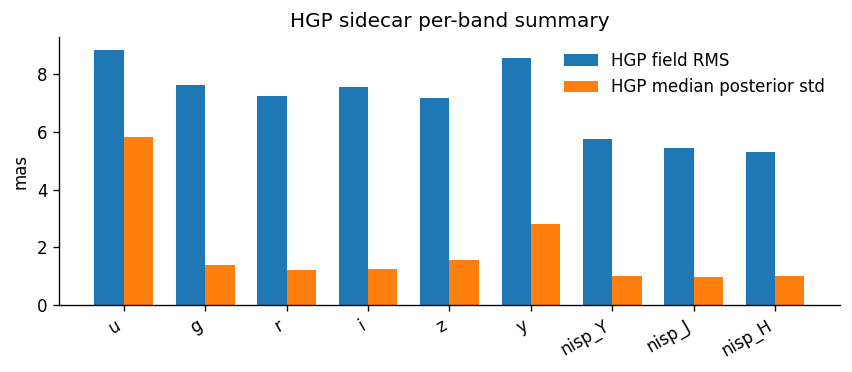

In [4]:
band_rows = []
for band, vals in hgp_meta['output']['bands'].items():
    band_rows.append({
        'band': band,
        'n_anchors': vals['n_anchors'],
        'hgp_field_rms_mas_json': vals['field_rms_mas'],
        'hgp_median_std_mas_json': vals['median_std_mas'],
    })
hgp_band_json = pd.DataFrame(band_rows)
display(hgp_band_json)

fig, ax = plt.subplots(figsize=(7.2, 3.2))
x = np.arange(len(hgp_band_json))
ax.bar(x - 0.18, hgp_band_json['hgp_field_rms_mas_json'], width=0.36, label='HGP field RMS')
ax.bar(x + 0.18, hgp_band_json['hgp_median_std_mas_json'], width=0.36, label='HGP median posterior std')
ax.set_xticks(x, hgp_band_json['band'], rotation=30, ha='right')
ax.set_ylabel('mas')
ax.set_title('HGP sidecar per-band summary')
ax.legend(frameon=False)
fig.tight_layout()

## 2. Compare HGP and PINN on the same sky grid

For each band, use the HGP WCS as the target grid and interpolate the PINN maps at those exact sky positions. All FITS values are in arcsec; the summary table reports milliarcseconds.

In [5]:
def grid_world_from_header(header):
    h = int(header['NAXIS2'])
    w = int(header['NAXIS1'])
    yy, xx = np.mgrid[:h, :w]
    ra, dec = WCS(header).wcs_pix2world(xx, yy, 0)
    return ra, dec


def sample_image_at_world(hdu, ra, dec, order=1):
    data = np.asarray(hdu.data, dtype=np.float64)
    x, y = WCS(hdu.header).wcs_world2pix(ra, dec, 0)
    sampled = map_coordinates(
        data,
        [y.ravel(), x.ravel()],
        order=order,
        mode='constant',
        cval=np.nan,
    ).reshape(ra.shape)
    return sampled


def amp_mas(dra_arcsec, dde_arcsec):
    return np.hypot(dra_arcsec, dde_arcsec) * 1000.0


def rms_amp_mas(dra_arcsec, dde_arcsec, mask=None):
    a = amp_mas(dra_arcsec, dde_arcsec)
    if mask is not None:
        a = a[mask]
    return float(np.sqrt(np.nanmean(a ** 2))) if np.isfinite(a).any() else np.nan


def median_amp_mas(dra_arcsec, dde_arcsec, mask=None):
    a = amp_mas(dra_arcsec, dde_arcsec)
    if mask is not None:
        a = a[mask]
    return float(np.nanmedian(a)) if np.isfinite(a).any() else np.nan


def load_resampled_band(band):
    with fits.open(HGP_FITS, memmap=True) as hgp, \
         fits.open(PINN_HEAD_FITS, memmap=True) as pinn_head, \
         fits.open(PINN_RAW_FITS, memmap=True) as pinn_raw:
        h_hdu = hgp[f'{band}.DRA']
        ra, dec = grid_world_from_header(h_hdu.header)
        out = {
            'ra': ra,
            'dec': dec,
            'hgp_dra': np.asarray(hgp[f'{band}.DRA'].data, dtype=np.float64),
            'hgp_dde': np.asarray(hgp[f'{band}.DDE'].data, dtype=np.float64),
            'hgp_dra_std': np.asarray(hgp[f'{band}.DRA_STD'].data, dtype=np.float64),
            'hgp_dde_std': np.asarray(hgp[f'{band}.DDE_STD'].data, dtype=np.float64),
            'hgp_coverage': np.asarray(hgp['COVERAGE'].data, dtype=np.float64) if 'COVERAGE' in hgp else np.ones_like(ra),
            'pinn_head_dra': sample_image_at_world(pinn_head[f'{band}.DRA'], ra, dec),
            'pinn_head_dde': sample_image_at_world(pinn_head[f'{band}.DDE'], ra, dec),
            'pinn_head_coverage': sample_image_at_world(pinn_head['COVERAGE'], ra, dec) if 'COVERAGE' in pinn_head else np.ones_like(ra),
            'pinn_raw_dra': sample_image_at_world(pinn_raw[f'{band}.DRA'], ra, dec),
            'pinn_raw_dde': sample_image_at_world(pinn_raw[f'{band}.DDE'], ra, dec),
        }
    return out


def finite_mask(d):
    finite = np.isfinite(d['hgp_dra']) & np.isfinite(d['hgp_dde'])
    finite &= np.isfinite(d['pinn_head_dra']) & np.isfinite(d['pinn_head_dde'])
    finite &= np.isfinite(d['pinn_raw_dra']) & np.isfinite(d['pinn_raw_dde'])
    finite &= np.isfinite(d['hgp_coverage']) & np.isfinite(d['pinn_head_coverage'])
    return finite


def support_mask(d, max_anchor_dist_arcsec=MAX_NEAREST_ANCHOR_ARCSEC, max_hgp_std_mas=MAX_HGP_STD_RADIAL_MAS):
    mask = finite_mask(d)
    mask &= d['hgp_coverage'] <= max_anchor_dist_arcsec
    mask &= d['pinn_head_coverage'] <= max_anchor_dist_arcsec
    if max_hgp_std_mas is not None:
        mask &= amp_mas(d['hgp_dra_std'], d['hgp_dde_std']) <= max_hgp_std_mas
    return mask

In [6]:
rows = []
for band in BANDS:
    d = load_resampled_band(band)
    m_full = finite_mask(d)
    m = support_mask(d)
    diff_dra = d['hgp_dra'] - d['pinn_head_dra']
    diff_dde = d['hgp_dde'] - d['pinn_head_dde']
    std_radial = amp_mas(d['hgp_dra_std'], d['hgp_dde_std'])
    rows.append({
        'band': BAND_LABEL[band],
        'n_full': int(m_full.sum()),
        'n_support': int(m.sum()),
        'support_frac': float(m.sum() / max(m_full.sum(), 1)),
        'hgp_rms_full_mas': rms_amp_mas(d['hgp_dra'], d['hgp_dde'], m_full),
        'hgp_median_support_mas': median_amp_mas(d['hgp_dra'], d['hgp_dde'], m),
        'hgp_rms_support_mas': rms_amp_mas(d['hgp_dra'], d['hgp_dde'], m),
        'pinn_head_rms_support_mas': rms_amp_mas(d['pinn_head_dra'], d['pinn_head_dde'], m),
        'hgp_minus_pinn_rms_support_mas': rms_amp_mas(diff_dra, diff_dde, m),
        'hgp_median_std_support_mas': float(np.nanmedian(std_radial[m])),
        'pinn_raw_rms_support_mas': rms_amp_mas(d['pinn_raw_dra'], d['pinn_raw_dde'], m),
    })

compare_df = pd.DataFrame(rows)
display(compare_df.round(3))

,band,n_full,n_support,support_frac,hgp_rms_full_mas,hgp_median_support_mas,hgp_rms_support_mas,pinn_head_rms_support_mas,hgp_minus_pinn_rms_support_mas,hgp_median_std_support_mas,pinn_raw_rms_support_mas
0,u,92227,79487,0.862,8.462,5.105,6.168,1.176,6.181,5.516,5.802
1,g,92227,85281,0.925,7.115,2.188,3.009,0.787,2.857,1.346,4.618
2,r,92227,85299,0.925,6.729,1.924,2.626,0.830,2.466,1.174,4.614
3,i,92227,85283,0.925,7.000,1.919,2.637,0.846,2.455,1.222,5.018
4,z,92227,85229,0.924,6.685,2.280,3.070,0.983,2.822,1.508,4.636
5,y,92227,84750,0.919,8.143,4.093,5.433,1.410,5.045,2.687,4.274
6,NISP Y,92227,85414,0.926,5.383,1.303,1.745,0.853,1.520,0.986,7.130
7,NISP J,92227,85414,0.926,5.083,1.260,1.702,0.889,1.463,0.954,7.403
8,NISP H,92227,85413,0.926,4.950,1.240,1.689,0.805,1.484,0.968,6.856


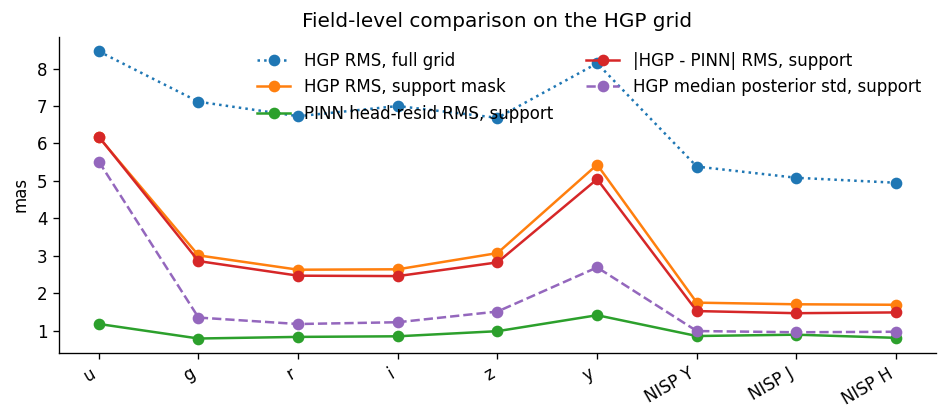

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(compare_df))
ax.plot(x, compare_df['hgp_rms_full_mas'], marker='o', linestyle=':', label='HGP RMS, full grid')
ax.plot(x, compare_df['hgp_rms_support_mas'], marker='o', label='HGP RMS, support mask')
ax.plot(x, compare_df['pinn_head_rms_support_mas'], marker='o', label='PINN head-resid RMS, support')
ax.plot(x, compare_df['hgp_minus_pinn_rms_support_mas'], marker='o', label='|HGP - PINN| RMS, support')
ax.plot(x, compare_df['hgp_median_std_support_mas'], marker='o', linestyle='--', label='HGP median posterior std, support')
ax.set_xticks(x, compare_df['band'], rotation=30, ha='right')
ax.set_ylabel('mas')
ax.set_title('Field-level comparison on the HGP grid')
ax.legend(frameon=False, ncol=2)
fig.tight_layout()

## 3. Map view for one band

Use this as the visual sanity check. The selected band defaults to Rubin `i`, but any entry from `BANDS` above can be used.

Text(0.5, 1.02, 'i: HGP vs PINN on the HGP grid')

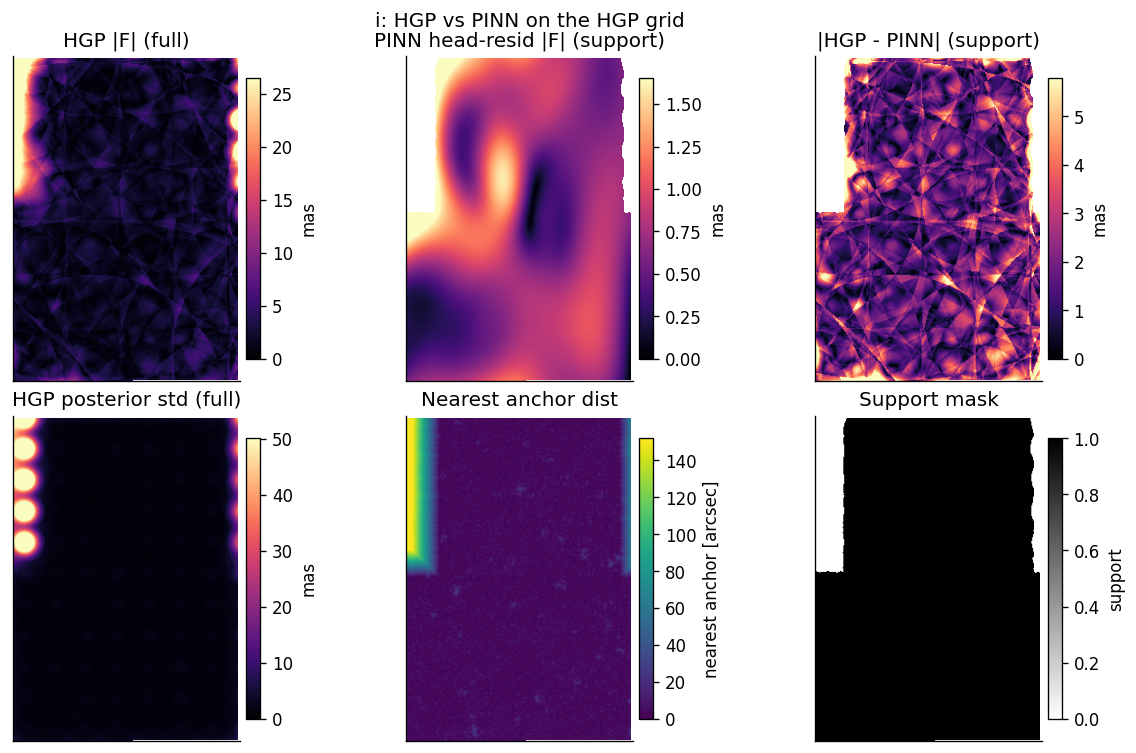

In [8]:
PLOT_BAND = 'I'
d = load_resampled_band(PLOT_BAND)
m_full = finite_mask(d)
m = support_mask(d)

maps = {
    'HGP |F| (full)': (amp_mas(d['hgp_dra'], d['hgp_dde']), m_full, 'mas'),
    'PINN head-resid |F| (support)': (amp_mas(d['pinn_head_dra'], d['pinn_head_dde']), m, 'mas'),
    '|HGP - PINN| (support)': (amp_mas(d['hgp_dra'] - d['pinn_head_dra'], d['hgp_dde'] - d['pinn_head_dde']), m, 'mas'),
    'HGP posterior std (full)': (amp_mas(d['hgp_dra_std'], d['hgp_dde_std']), m_full, 'mas'),
    'Nearest anchor dist': (d['hgp_coverage'], m_full, 'arcsec'),
    'Support mask': (m.astype(float), m_full, 'mask'),
}

fig, axes = plt.subplots(2, 3, figsize=(10, 6), constrained_layout=True)
for ax, (title, (image, mask, unit)) in zip(axes.ravel(), maps.items()):
    show = np.asarray(image, dtype=np.float64).copy()
    show[~mask] = np.nan
    if unit == 'arcsec':
        vmin, vmax, cmap = 0, np.nanpercentile(show, 99), 'viridis'
        label = 'nearest anchor [arcsec]'
    elif unit == 'mask':
        vmin, vmax, cmap = 0, 1, 'gray_r'
        label = 'support'
    else:
        vmin, vmax, cmap = 0, np.nanpercentile(show, 98), 'magma'
        label = 'mas'
    im = ax.imshow(show, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label=label)

fig.suptitle(f'{BAND_LABEL[PLOT_BAND]}: HGP vs PINN on the HGP grid', y=1.02)

Text(0.5, 0.98, 'i vector-component agreement')

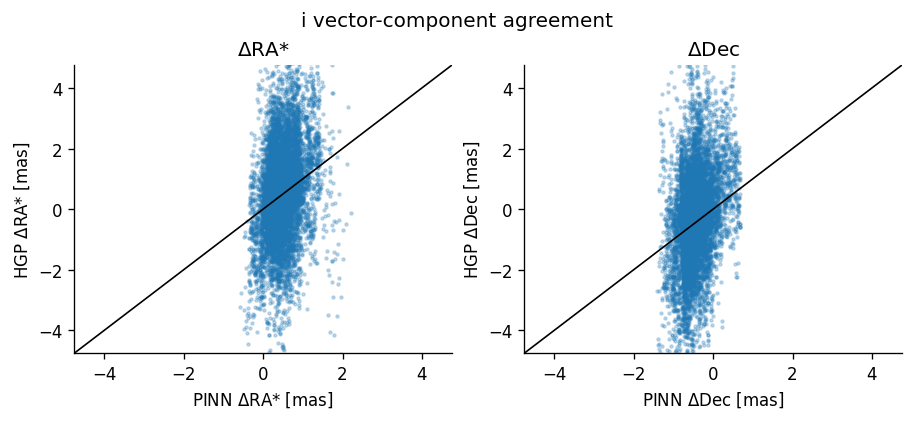

In [9]:
rng = np.random.default_rng(42)
idx = np.flatnonzero(m.ravel())
idx = rng.choice(idx, size=min(8000, idx.size), replace=False)

hgp_dra = d['hgp_dra'].ravel()[idx] * 1000
hgp_dde = d['hgp_dde'].ravel()[idx] * 1000
pinn_dra = d['pinn_head_dra'].ravel()[idx] * 1000
pinn_dde = d['pinn_head_dde'].ravel()[idx] * 1000

lim = np.nanpercentile(np.abs(np.r_[hgp_dra, hgp_dde, pinn_dra, pinn_dde]), 99)
lim = max(lim, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.4), constrained_layout=True)
for ax, hgp_val, pinn_val, name in [
    (axes[0], hgp_dra, pinn_dra, r'$\Delta$RA*'),
    (axes[1], hgp_dde, pinn_dde, r'$\Delta$Dec'),
]:
    ax.scatter(pinn_val, hgp_val, s=3, alpha=0.25, rasterized=True)
    ax.plot([-lim, lim], [-lim, lim], color='black', lw=1)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(f'PINN {name} [mas]')
    ax.set_ylabel(f'HGP {name} [mas]')
    ax.set_title(name)
fig.suptitle(f'{BAND_LABEL[PLOT_BAND]} vector-component agreement')

## 4. HGP hierarchical decomposition

This is the main thing PINN did not give us directly: a split between common, instrument-group and band-specific smooth structure. The numbers below are field RMS values from the HGP output sidecar.

,component,field_rms_mas
10,BAND_NISP_J,0.640897
11,BAND_NISP_H,0.734114
9,BAND_NISP_Y,0.742044
7,BAND_Z,1.643990
2,GROUP_NISP,1.724400
5,BAND_R,1.797363
4,BAND_G,1.818616
6,BAND_I,1.859808
1,GROUP_RUBIN,2.283051
8,BAND_Y,3.585136


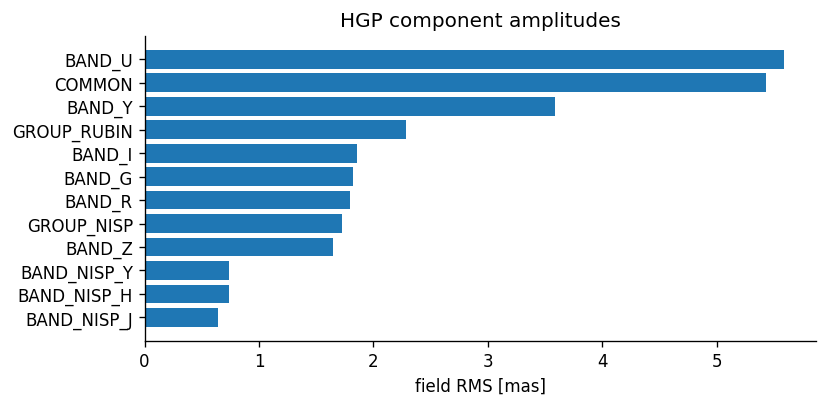

In [10]:
component_df = (
    pd.DataFrame([
        {'component': name, 'field_rms_mas': vals['field_rms_mas']}
        for name, vals in hgp_meta['output'].get('components', {}).items()
    ])
    .sort_values('field_rms_mas', ascending=True)
)
display(component_df)

fig, ax = plt.subplots(figsize=(7, max(3.5, 0.22 * len(component_df))))
ax.barh(component_df['component'], component_df['field_rms_mas'])
ax.set_xlabel('field RMS [mas]')
ax.set_title('HGP component amplitudes')
fig.tight_layout()

## 5. Anchor-level zero-field sanity check

A smooth field should improve the residuals at the actual anchors, not only make a visually structured map. This cell samples HGP and PINN at the CenterNet head-residual anchor positions and compares both to the zero-field baseline. If the median residual barely changes, the fitted smooth field is below the source-level noise floor.

In [11]:
ANCHORS = CKPT / 'anchors_centernet.npz'
BAND_KEY = {'U': 'u', 'G': 'g', 'R': 'r', 'I': 'i', 'Z': 'z', 'Y': 'y',
            'NISP_Y': 'nisp_Y', 'NISP_J': 'nisp_J', 'NISP_H': 'nisp_H'}


def sample_field_pair(hdul, band, ra, dec, suffix=''):
    prefix = band
    dra = sample_image_at_world(hdul[f'{prefix}.DRA{suffix}'], ra, dec)
    dde = sample_image_at_world(hdul[f'{prefix}.DDE{suffix}'], ra, dec)
    return np.stack([dra, dde], axis=1)


anchor_rows = []
anchors = np.load(ANCHORS, allow_pickle=True)
with fits.open(HGP_FITS, memmap=True) as hgp, fits.open(PINN_HEAD_FITS, memmap=True) as pinn:
    for band in BANDS:
        key = BAND_KEY[band]
        ra = anchors[f'{key}_ra']
        dec = anchors[f'{key}_dec']
        off = anchors[f'{key}_head_resid'].astype(np.float64)
        hgp_pred = sample_field_pair(hgp, band, ra, dec)
        pinn_pred = sample_field_pair(pinn, band, ra, dec)
        hgp_std = sample_field_pair(hgp, band, ra, dec, suffix='_STD')
        hgp_dist = sample_image_at_world(hgp['COVERAGE'], ra, dec)
        pinn_dist = sample_image_at_world(pinn['COVERAGE'], ra, dec)
        finite = (
            np.isfinite(off).all(axis=1)
            & np.isfinite(hgp_pred).all(axis=1)
            & np.isfinite(pinn_pred).all(axis=1)
            & np.isfinite(hgp_std).all(axis=1)
            & np.isfinite(hgp_dist)
            & np.isfinite(pinn_dist)
        )
        finite &= amp_mas(off[:, 0], off[:, 1]) < 200.0
        support = finite & (hgp_dist <= MAX_NEAREST_ANCHOR_ARCSEC) & (pinn_dist <= MAX_NEAREST_ANCHOR_ARCSEC)
        support &= amp_mas(hgp_std[:, 0], hgp_std[:, 1]) <= MAX_HGP_STD_RADIAL_MAS
        for name, mask in [('finite', finite), ('support', support)]:
            if not mask.any():
                continue
            zero = amp_mas(off[mask, 0], off[mask, 1])
            after_hgp = amp_mas(off[mask, 0] - hgp_pred[mask, 0], off[mask, 1] - hgp_pred[mask, 1])
            after_pinn = amp_mas(off[mask, 0] - pinn_pred[mask, 0], off[mask, 1] - pinn_pred[mask, 1])
            anchor_rows.append({
                'band': BAND_LABEL[band],
                'mask': name,
                'n': int(mask.sum()),
                'zero_field_med_mas': float(np.nanmedian(zero)),
                'hgp_after_med_mas': float(np.nanmedian(after_hgp)),
                'pinn_after_med_mas': float(np.nanmedian(after_pinn)),
                'hgp_delta_med_mas': float(np.nanmedian(zero) - np.nanmedian(after_hgp)),
                'pinn_delta_med_mas': float(np.nanmedian(zero) - np.nanmedian(after_pinn)),
                'hgp_field_med_mas': median_amp_mas(hgp_pred[:, 0], hgp_pred[:, 1], mask),
                'pinn_field_med_mas': median_amp_mas(pinn_pred[:, 0], pinn_pred[:, 1], mask),
                'hgp_std_med_mas': median_amp_mas(hgp_std[:, 0], hgp_std[:, 1], mask),
                'nearest_anchor_p95_arcsec': float(np.nanpercentile(hgp_dist[mask], 95)),
            })

anchor_df = pd.DataFrame(anchor_rows)
display(anchor_df.round(3))

weighted = []
for mask_name, group in anchor_df.groupby('mask'):
    weights = group['n'].to_numpy()
    weighted.append({
        'mask': mask_name,
        'n_total': int(weights.sum()),
        'hgp_delta_source_weighted_mas': float(np.average(group['hgp_delta_med_mas'], weights=weights)),
        'pinn_delta_source_weighted_mas': float(np.average(group['pinn_delta_med_mas'], weights=weights)),
    })
display(pd.DataFrame(weighted).round(4))

,band,mask,n,zero_field_med_mas,hgp_after_med_mas,pinn_after_med_mas,hgp_delta_med_mas,pinn_delta_med_mas,hgp_field_med_mas,pinn_field_med_mas,hgp_std_med_mas,nearest_anchor_p95_arcsec
0,u,finite,9581,23.399,22.922,23.260,0.476,0.139,5.158,1.012,5.406,3.164
1,u,support,9336,23.270,22.864,23.134,0.406,0.136,5.101,1.012,5.363,3.166
2,g,finite,47216,9.457,9.535,9.412,-0.078,0.045,2.037,0.669,1.297,3.174
3,g,support,47216,9.457,9.535,9.412,-0.078,0.045,2.037,0.669,1.297,3.174
4,r,finite,54777,8.712,8.740,8.694,-0.028,0.018,1.801,0.711,1.134,3.172
5,r,support,54777,8.712,8.740,8.694,-0.028,0.018,1.801,0.711,1.134,3.172
6,i,finite,48962,8.624,8.610,8.597,0.013,0.026,1.808,0.773,1.182,3.170
7,i,support,48962,8.624,8.610,8.597,0.013,0.026,1.808,0.773,1.182,3.170
8,z,finite,35147,9.360,9.330,9.304,0.030,0.056,2.097,0.883,1.453,3.188
9,z,support,35146,9.360,9.330,9.304,0.030,0.056,2.097,0.883,1.453,3.188


,mask,n_total,hgp_delta_source_weighted_mas,pinn_delta_source_weighted_mas
0,finite,491364,0.0111,0.0268
1,support,491116,0.0095,0.0267


## Reading the first result

- The HGP `COVERAGE` extension is a nearest-anchor distance map in arcsec. Large values mean weak support / extrapolation, not high anchor density.
- Compare the support-masked columns before interpreting field amplitudes. The full-grid HGP RMS is useful as an edge-extrapolation diagnostic, not as an astrometric correction claim.
- `|HGP - PINN| RMS` is the model-disagreement scale, not a new astrometric residual.
- `HGP posterior std` is the uncertainty of the fitted smooth field under the HGP model after holdout calibration.
- `PINN raw |F|` is context for the pre-head coherent field; the fair post-head comparison is HGP head-residual vs PINN head-residual.
- The HGP output grid is sampled every 5 arcsec on the sky. That is a spatial sampling interval, not a 5 mas accuracy floor. Sub-mas-valued corrections can be stored on a 5 arcsec grid if the fitted field is smooth on scales much larger than 5 arcsec.
- The current caution is not the grid size. The caution is the model comparison: the CenterNet PINN head-residual field is near 1 mas RMS, while HGP is several mas RMS and is dominated by the common component. Before using the HGP correction as the production field, inspect whether the HGP hierarchy/priors are absorbing residual source noise into a coherent common field.

## 6. Raw-anchor sanity check: HGP vs PINN before the head

The head-residual comparison above is only meaningful if the two solvers agree on what the smooth field looks like *before* the head touches it. The PINN raw fit (`concordance_pinn_centernet_raw.fits`) recovers the ECDFS ~5-9 mas raw concordance. This section refits HGP on the same raw anchors and checks two things:

1. **Method-independence on raw**: do HGP and PINN find the same raw smooth field, on supported regions?
2. **Anchor-level signal on raw**: does subtracting either field improve raw `|offset|` residuals at the actual anchor positions, or are they tied with the zero-field baseline?

If HGP and PINN agree on raw and disagree on head_resid, the head-residual disagreement is genuinely about the post-head ~1 mas regime, not about the solvers themselves. If they disagree on raw too, the disagreement is intrinsic to the priors/regularizers.

The raw HGP FITS is produced with the same length scales / hierarchy as the head-residual run, only with `--offset-kind raw`:

```bash
python -m models.astrometry2.fit_hierarchical_gp_concordance \
    --anchors models/checkpoints/latent_position_v8_no_psf/anchors_centernet.npz \
    --output  models/checkpoints/latent_position_v8_no_psf/concordance_hgp_centernet_raw.fits \
    --offset-kind raw --bands u,g,r,i,z,y,nisp_Y,nisp_J,nisp_H \
    --length-scales 45,120,300,900 --max-centers-per-scale 120 \
    --prior-common-mas 25.0 --prior-group-mas 12.0 --prior-band-mas 6.0 \
    --robust-iters 3 --huber-k 3.0 --dstep-arcsec 5.0 \
    --holdout-mode spatial --save-components --write-coverage --seed 42
```

In [12]:
HGP_RAW_FITS = CKPT / 'concordance_hgp_centernet_raw.fits'
HGP_RAW_JSON = HGP_RAW_FITS.with_suffix('.fits.json')


def have_raw_hgp():
    if not HGP_RAW_FITS.exists():
        print(f"Raw-anchor HGP FITS not found at {HGP_RAW_FITS.relative_to(ROOT)}.")
        print("Run the CLI command from the markdown above to produce it (~8 min on this anchor cache),")
        print("then re-execute this section.")
        return False
    return True


def load_resampled_band_raw(band):
    """Sample HGP_RAW and PINN_RAW on the HGP_RAW grid for one band."""
    with fits.open(HGP_RAW_FITS, memmap=True) as hgp, \
         fits.open(PINN_RAW_FITS, memmap=True) as pinn:
        h_hdu = hgp[f'{band}.DRA']
        ra, dec = grid_world_from_header(h_hdu.header)
        return {
            'ra': ra, 'dec': dec,
            'hgp_dra': np.asarray(hgp[f'{band}.DRA'].data, dtype=np.float64),
            'hgp_dde': np.asarray(hgp[f'{band}.DDE'].data, dtype=np.float64),
            'hgp_dra_std': np.asarray(hgp[f'{band}.DRA_STD'].data, dtype=np.float64),
            'hgp_dde_std': np.asarray(hgp[f'{band}.DDE_STD'].data, dtype=np.float64),
            'hgp_coverage': np.asarray(hgp['COVERAGE'].data, dtype=np.float64) if 'COVERAGE' in hgp else np.ones_like(ra),
            'pinn_dra': sample_image_at_world(pinn[f'{band}.DRA'], ra, dec),
            'pinn_dde': sample_image_at_world(pinn[f'{band}.DDE'], ra, dec),
            'pinn_coverage': sample_image_at_world(pinn['COVERAGE'], ra, dec) if 'COVERAGE' in pinn else np.ones_like(ra),
        }


def finite_mask_raw(d):
    finite = np.isfinite(d['hgp_dra']) & np.isfinite(d['hgp_dde'])
    finite &= np.isfinite(d['pinn_dra']) & np.isfinite(d['pinn_dde'])
    finite &= np.isfinite(d['hgp_coverage']) & np.isfinite(d['pinn_coverage'])
    return finite


def support_mask_raw(d, max_anchor_dist_arcsec=MAX_NEAREST_ANCHOR_ARCSEC, max_hgp_std_mas=MAX_HGP_STD_RADIAL_MAS):
    mask = finite_mask_raw(d)
    mask &= d['hgp_coverage'] <= max_anchor_dist_arcsec
    mask &= d['pinn_coverage'] <= max_anchor_dist_arcsec
    if max_hgp_std_mas is not None:
        mask &= amp_mas(d['hgp_dra_std'], d['hgp_dde_std']) <= max_hgp_std_mas
    return mask


if have_raw_hgp():
    rows_raw = []
    for band in BANDS:
        d = load_resampled_band_raw(band)
        m_full = finite_mask_raw(d)
        m = support_mask_raw(d)
        diff_dra = d['hgp_dra'] - d['pinn_dra']
        diff_dde = d['hgp_dde'] - d['pinn_dde']
        std_radial = amp_mas(d['hgp_dra_std'], d['hgp_dde_std'])
        rows_raw.append({
            'band': BAND_LABEL[band],
            'n_full': int(m_full.sum()),
            'n_support': int(m.sum()),
            'support_frac': float(m.sum() / max(m_full.sum(), 1)),
            'hgp_raw_rms_full_mas': rms_amp_mas(d['hgp_dra'], d['hgp_dde'], m_full),
            'hgp_raw_median_support_mas': median_amp_mas(d['hgp_dra'], d['hgp_dde'], m),
            'hgp_raw_rms_support_mas': rms_amp_mas(d['hgp_dra'], d['hgp_dde'], m),
            'pinn_raw_rms_support_mas': rms_amp_mas(d['pinn_dra'], d['pinn_dde'], m),
            'hgp_minus_pinn_raw_rms_support_mas': rms_amp_mas(diff_dra, diff_dde, m),
            'hgp_raw_median_std_support_mas': float(np.nanmedian(std_radial[m])),
        })
    compare_raw_df = pd.DataFrame(rows_raw)
    display(compare_raw_df.round(3))

,band,n_full,n_support,support_frac,hgp_raw_rms_full_mas,hgp_raw_median_support_mas,hgp_raw_rms_support_mas,pinn_raw_rms_support_mas,hgp_minus_pinn_raw_rms_support_mas,hgp_raw_median_std_support_mas
0,u,92710,12306,0.133,13.694,9.891,11.674,5.909,9.499,9.676
1,g,92710,84254,0.909,8.865,5.766,6.958,4.601,5.855,3.810
2,r,92710,84845,0.915,9.194,5.335,6.476,4.617,4.888,3.158
3,i,92710,84931,0.916,9.309,5.939,6.920,5.013,4.969,3.041
4,z,92710,84488,0.911,9.385,5.386,6.672,4.633,5.544,3.552
5,y,92710,78644,0.848,10.062,6.074,7.685,4.279,7.359,5.862
6,NISP Y,92710,85271,0.920,10.326,7.882,8.756,7.111,4.585,2.800
7,NISP J,92710,85276,0.920,11.694,8.343,9.166,7.401,4.677,2.778
8,NISP H,92710,85277,0.920,11.042,7.661,8.763,6.829,4.720,2.798


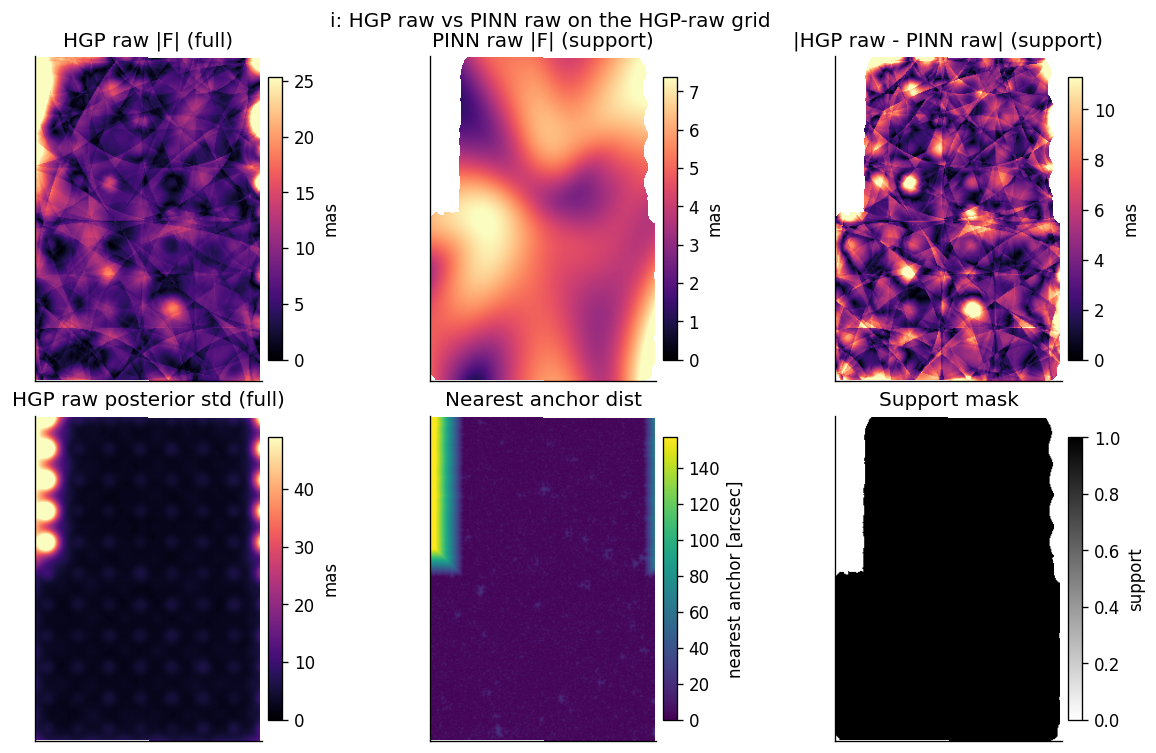

In [13]:
if have_raw_hgp():
    PLOT_BAND_RAW = 'I'
    d = load_resampled_band_raw(PLOT_BAND_RAW)
    m_full = finite_mask_raw(d)
    m = support_mask_raw(d)

    maps_raw = {
        'HGP raw |F| (full)':              (amp_mas(d['hgp_dra'], d['hgp_dde']), m_full, 'mas'),
        'PINN raw |F| (support)':          (amp_mas(d['pinn_dra'], d['pinn_dde']), m, 'mas'),
        '|HGP raw - PINN raw| (support)':  (amp_mas(d['hgp_dra'] - d['pinn_dra'], d['hgp_dde'] - d['pinn_dde']), m, 'mas'),
        'HGP raw posterior std (full)':    (amp_mas(d['hgp_dra_std'], d['hgp_dde_std']), m_full, 'mas'),
        'Nearest anchor dist':             (d['hgp_coverage'], m_full, 'arcsec'),
        'Support mask':                    (m.astype(float), m_full, 'mask'),
    }

    fig, axes = plt.subplots(2, 3, figsize=(10, 6), constrained_layout=True)
    for ax, (title, (image, mask, unit)) in zip(axes.ravel(), maps_raw.items()):
        show = np.asarray(image, dtype=np.float64).copy()
        show[~mask] = np.nan
        if unit == 'arcsec':
            vmin, vmax, cmap = 0, np.nanpercentile(show, 99), 'viridis'
            label = 'nearest anchor [arcsec]'
        elif unit == 'mask':
            vmin, vmax, cmap = 0, 1, 'gray_r'
            label = 'support'
        else:
            vmin, vmax, cmap = 0, np.nanpercentile(show, 98), 'magma'
            label = 'mas'
        im = ax.imshow(show, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label=label)
    fig.suptitle(f'{BAND_LABEL[PLOT_BAND_RAW]}: HGP raw vs PINN raw on the HGP-raw grid', y=1.02)

In [14]:
if have_raw_hgp():
    anchor_raw_rows = []
    with fits.open(HGP_RAW_FITS, memmap=True) as hgp_raw, \
         fits.open(PINN_RAW_FITS, memmap=True) as pinn_raw:
        for band in BANDS:
            key = BAND_KEY[band]
            ra = anchors[f'{key}_ra']
            dec = anchors[f'{key}_dec']
            off = anchors[f'{key}_raw'].astype(np.float64)
            hgp_pred = sample_field_pair(hgp_raw, band, ra, dec)
            pinn_pred = sample_field_pair(pinn_raw, band, ra, dec)
            hgp_std = sample_field_pair(hgp_raw, band, ra, dec, suffix='_STD')
            hgp_dist = sample_image_at_world(hgp_raw['COVERAGE'], ra, dec)
            pinn_dist = sample_image_at_world(pinn_raw['COVERAGE'], ra, dec)
            finite = (
                np.isfinite(off).all(axis=1)
                & np.isfinite(hgp_pred).all(axis=1)
                & np.isfinite(pinn_pred).all(axis=1)
                & np.isfinite(hgp_std).all(axis=1)
                & np.isfinite(hgp_dist) & np.isfinite(pinn_dist)
            )
            finite &= amp_mas(off[:, 0], off[:, 1]) < 200.0
            support = finite & (hgp_dist <= MAX_NEAREST_ANCHOR_ARCSEC) & (pinn_dist <= MAX_NEAREST_ANCHOR_ARCSEC)
            support &= amp_mas(hgp_std[:, 0], hgp_std[:, 1]) <= MAX_HGP_STD_RADIAL_MAS
            for name, mask in [('finite', finite), ('support', support)]:
                if not mask.any():
                    continue
                zero = amp_mas(off[mask, 0], off[mask, 1])
                after_hgp = amp_mas(off[mask, 0] - hgp_pred[mask, 0], off[mask, 1] - hgp_pred[mask, 1])
                after_pinn = amp_mas(off[mask, 0] - pinn_pred[mask, 0], off[mask, 1] - pinn_pred[mask, 1])
                anchor_raw_rows.append({
                    'band': BAND_LABEL[band],
                    'mask': name,
                    'n': int(mask.sum()),
                    'zero_field_med_mas': float(np.nanmedian(zero)),
                    'hgp_after_med_mas': float(np.nanmedian(after_hgp)),
                    'pinn_after_med_mas': float(np.nanmedian(after_pinn)),
                    'hgp_delta_med_mas': float(np.nanmedian(zero) - np.nanmedian(after_hgp)),
                    'pinn_delta_med_mas': float(np.nanmedian(zero) - np.nanmedian(after_pinn)),
                    'hgp_field_med_mas': median_amp_mas(hgp_pred[:, 0], hgp_pred[:, 1], mask),
                    'pinn_field_med_mas': median_amp_mas(pinn_pred[:, 0], pinn_pred[:, 1], mask),
                    'hgp_std_med_mas': median_amp_mas(hgp_std[:, 0], hgp_std[:, 1], mask),
                })

    anchor_raw_df = pd.DataFrame(anchor_raw_rows)
    display(anchor_raw_df.round(3))

    weighted_raw = []
    for mask_name, group in anchor_raw_df.groupby('mask'):
        weights = group['n'].to_numpy()
        weighted_raw.append({
            'mask': mask_name,
            'n_total': int(weights.sum()),
            'hgp_delta_source_weighted_mas': float(np.average(group['hgp_delta_med_mas'], weights=weights)),
            'pinn_delta_source_weighted_mas': float(np.average(group['pinn_delta_med_mas'], weights=weights)),
        })
    display(pd.DataFrame(weighted_raw).round(4))

,band,mask,n,zero_field_med_mas,hgp_after_med_mas,pinn_after_med_mas,hgp_delta_med_mas,pinn_delta_med_mas,hgp_field_med_mas,pinn_field_med_mas,hgp_std_med_mas
0,u,finite,9582,115.613,114.571,115.476,1.042,0.137,10.255,5.555,11.291
1,u,support,1736,109.827,108.844,109.259,0.983,0.568,9.512,5.474,9.657
2,g,finite,47219,48.089,47.623,47.928,0.466,0.161,5.669,4.465,3.694
3,g,support,47124,48.105,47.621,47.936,0.484,0.169,5.663,4.463,3.693
4,r,finite,54787,40.185,39.851,39.984,0.335,0.202,5.231,4.517,3.057
5,r,support,54761,40.191,39.867,39.989,0.325,0.203,5.229,4.516,3.057
6,i,finite,48970,36.232,35.722,36.100,0.509,0.132,5.826,4.814,2.942
7,i,support,48948,36.224,35.716,36.087,0.508,0.137,5.825,4.813,2.942
8,z,finite,35160,37.298,36.817,36.975,0.481,0.322,5.213,4.224,3.429
9,z,support,35132,37.285,36.819,36.975,0.466,0.310,5.210,4.226,3.428


,mask,n_total,hgp_delta_source_weighted_mas,pinn_delta_source_weighted_mas
0,finite,491419,0.6935,0.4851
1,support,482698,0.6906,0.4870


### How to read this section

- **Same field, two solvers**: in section 5 the head-residual baseline is ~9 mas per source and the smooth field is ~1 mas. On raw, the per-source baseline is ~8-9 mas (Rubin) / ~7-8 mas (NISP) too — but the *coherent* component is much larger, so subtracting either field should bite. If `hgp_delta_med_mas` and `pinn_delta_med_mas` are now both clearly positive (e.g. tenths of a mas to ~1 mas), there is a real signal here that the head-residual test was below; if they are still essentially tied with zero, there is no smooth concordance to recover even on raw.
- **`hgp_minus_pinn_raw_rms_support_mas`** is the model-disagreement scale on raw. Compare it to each solver's individual support RMS. Agreement is method-independence; disagreement at >~1-2 mas means the priors are doing real work even on raw, so the head-resid disagreement above is partly inherited.
- **HGP raw posterior std** should be smaller than the supported HGP raw RMS (signal > uncertainty). If it is comparable, the field is not detected over the HGP noise model.
- **NISP vs Rubin**: the PINN raw fit shows NISP at ~7 mas and Rubin (g/r/i/z) at ~5 mas. If HGP roughly tracks that ordering, the Rubin/NISP common+group structure in section 4 is consistent. If HGP collapses everything to a single common field with similar amplitude across instruments, that points back to the prior absorbing real per-instrument structure.
- **Compared to the head-residual test (section 5)**: a clear `pinn_delta` and `hgp_delta` here, alongside near-zero deltas there, is the cleanest way to say "the head ate the smooth field"; deltas that are similarly small in both raw and head-residual would say "no smooth field is recoverable at all in this footprint."

## 7. Tighter-prior HGP raw refit

The Section 6 HGP raw map traced per-tile noise instead of a smooth degree-scale field, with `|HGP - PINN|` of order the PINN signal itself. This section repeats the HGP raw fit with two changes designed to suppress that failure mode:

1. **Drop the 45 arcsec length scale**: keep only 120/300/900. Per-tile structure cannot be fit by basis functions whose minimum scale is larger than a typical tile span.
2. **Tighten the hierarchical priors**: `--prior-common-mas 8` (was 25), `--prior-group-mas 6` (was 12), `--prior-band-mas 4` (was 6). The looser values let the common component absorb noise; tightening forces HGP to spend amplitude only on structure shared across instruments at degree scale.

```bash
python -m models.astrometry2.fit_hierarchical_gp_concordance \
    --anchors models/checkpoints/latent_position_v8_no_psf/anchors_centernet.npz \
    --output  models/checkpoints/latent_position_v8_no_psf/concordance_hgp_centernet_raw_tight.fits \
    --offset-kind raw --bands u,g,r,i,z,y,nisp_Y,nisp_J,nisp_H \
    --length-scales 120,300,900 --max-centers-per-scale 120 \
    --prior-common-mas 8.0 --prior-group-mas 6.0 --prior-band-mas 4.0 \
    --robust-iters 3 --huber-k 3.0 --dstep-arcsec 5.0 \
    --holdout-mode spatial --save-components --write-coverage --seed 42
```

Success criterion: `|HGP_tight - PINN|` RMS drops well below the PINN signal, and the HGP map looks smooth (no tile criss-cross). Failure means HGP's hierarchical-Gaussian formulation cannot mimic PINN's curl-free / Laplacian / band-consistency priors no matter how it is tuned, and the trustworthy raw cross-checks remain PINN, NN, and the sklearn GP from Notebook 07.

In [15]:
HGP_RAW_TIGHT_FITS = CKPT / 'concordance_hgp_centernet_raw_tight.fits'


def have_raw_hgp_tight():
    if not HGP_RAW_TIGHT_FITS.exists():
        print(f"Tight raw HGP FITS not found at {HGP_RAW_TIGHT_FITS.relative_to(ROOT)}.")
        return False
    return True


def load_resampled_band_raw_tight(band):
    with fits.open(HGP_RAW_TIGHT_FITS, memmap=True) as hgp, \
         fits.open(PINN_RAW_FITS, memmap=True) as pinn, \
         fits.open(HGP_RAW_FITS, memmap=True) as hgp_old:
        h_hdu = hgp[f'{band}.DRA']
        ra, dec = grid_world_from_header(h_hdu.header)
        return {
            'ra': ra, 'dec': dec,
            'hgp_dra': np.asarray(hgp[f'{band}.DRA'].data, dtype=np.float64),
            'hgp_dde': np.asarray(hgp[f'{band}.DDE'].data, dtype=np.float64),
            'hgp_dra_std': np.asarray(hgp[f'{band}.DRA_STD'].data, dtype=np.float64),
            'hgp_dde_std': np.asarray(hgp[f'{band}.DDE_STD'].data, dtype=np.float64),
            'hgp_coverage': np.asarray(hgp['COVERAGE'].data, dtype=np.float64) if 'COVERAGE' in hgp else np.ones_like(ra),
            'pinn_dra': sample_image_at_world(pinn[f'{band}.DRA'], ra, dec),
            'pinn_dde': sample_image_at_world(pinn[f'{band}.DDE'], ra, dec),
            'pinn_coverage': sample_image_at_world(pinn['COVERAGE'], ra, dec) if 'COVERAGE' in pinn else np.ones_like(ra),
            'hgp_old_dra': sample_image_at_world(hgp_old[f'{band}.DRA'], ra, dec),
            'hgp_old_dde': sample_image_at_world(hgp_old[f'{band}.DDE'], ra, dec),
        }


def support_mask_tight(d, max_anchor_dist=MAX_NEAREST_ANCHOR_ARCSEC, max_hgp_std_mas=MAX_HGP_STD_RADIAL_MAS):
    mask = np.isfinite(d['hgp_dra']) & np.isfinite(d['hgp_dde'])
    mask &= np.isfinite(d['pinn_dra']) & np.isfinite(d['pinn_dde'])
    mask &= np.isfinite(d['hgp_old_dra']) & np.isfinite(d['hgp_old_dde'])
    mask &= np.isfinite(d['hgp_coverage']) & np.isfinite(d['pinn_coverage'])
    mask &= d['hgp_coverage'] <= max_anchor_dist
    mask &= d['pinn_coverage'] <= max_anchor_dist
    if max_hgp_std_mas is not None:
        mask &= amp_mas(d['hgp_dra_std'], d['hgp_dde_std']) <= max_hgp_std_mas
    return mask


if have_raw_hgp_tight():
    rows_tight = []
    for band in BANDS:
        d = load_resampled_band_raw_tight(band)
        m = support_mask_tight(d)
        rows_tight.append({
            'band': BAND_LABEL[band],
            'n_support': int(m.sum()),
            'hgp_tight_rms_mas': rms_amp_mas(d['hgp_dra'], d['hgp_dde'], m),
            'hgp_orig_rms_mas': rms_amp_mas(d['hgp_old_dra'], d['hgp_old_dde'], m),
            'pinn_rms_mas': rms_amp_mas(d['pinn_dra'], d['pinn_dde'], m),
            'tight_minus_pinn_rms_mas': rms_amp_mas(d['hgp_dra'] - d['pinn_dra'], d['hgp_dde'] - d['pinn_dde'], m),
            'orig_minus_pinn_rms_mas': rms_amp_mas(d['hgp_old_dra'] - d['pinn_dra'], d['hgp_old_dde'] - d['pinn_dde'], m),
            'tight_minus_orig_rms_mas': rms_amp_mas(d['hgp_dra'] - d['hgp_old_dra'], d['hgp_dde'] - d['hgp_old_dde'], m),
            'hgp_tight_std_mas': float(np.nanmedian(amp_mas(d['hgp_dra_std'], d['hgp_dde_std'])[m])),
        })
    compare_tight_df = pd.DataFrame(rows_tight)
    display(compare_tight_df.round(3))

,band,n_support,hgp_tight_rms_mas,hgp_orig_rms_mas,pinn_rms_mas,tight_minus_pinn_rms_mas,orig_minus_pinn_rms_mas,tight_minus_orig_rms_mas,hgp_tight_std_mas
0,u,67551,10.477,12.355,5.857,8.103,10.244,4.193,8.347
1,g,85647,5.409,7.114,4.624,3.938,6.013,3.882,2.716
2,r,85672,5.365,6.589,4.616,3.370,5.014,3.194,2.237
3,i,85674,6.034,7.047,5.023,3.697,5.147,3.007,2.151
4,z,85659,5.461,6.843,4.643,3.952,5.754,3.470,2.525
5,y,85128,5.861,8.098,4.273,5.500,7.851,4.523,4.324
6,NISP Y,85676,8.219,8.782,7.132,3.423,4.643,2.808,1.990
7,NISP J,85676,8.665,9.205,7.406,3.558,4.736,2.729,1.975
8,NISP H,85676,8.196,8.818,6.860,3.521,4.790,2.807,1.989


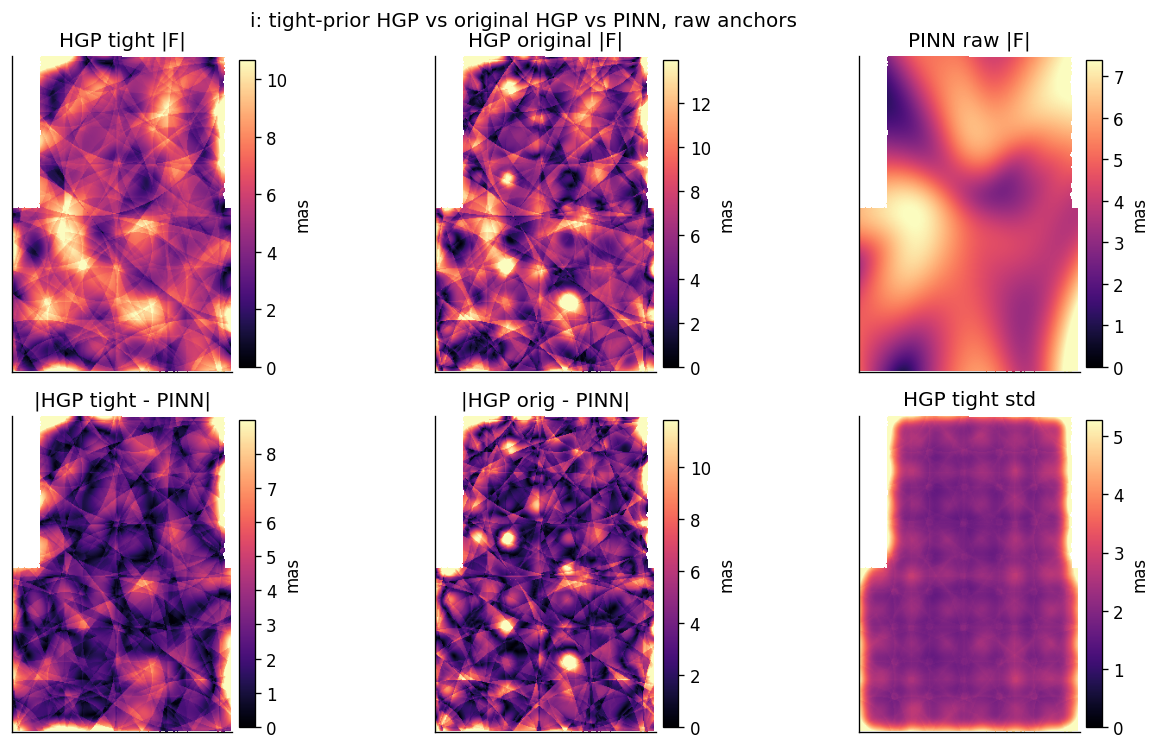

In [16]:
if have_raw_hgp_tight():
    PLOT_BAND_TIGHT = 'I'
    d = load_resampled_band_raw_tight(PLOT_BAND_TIGHT)
    m = support_mask_tight(d)

    panels = {
        'HGP tight |F|':       (amp_mas(d['hgp_dra'], d['hgp_dde']),                 m, 'mas'),
        'HGP original |F|':    (amp_mas(d['hgp_old_dra'], d['hgp_old_dde']),         m, 'mas'),
        'PINN raw |F|':        (amp_mas(d['pinn_dra'], d['pinn_dde']),               m, 'mas'),
        '|HGP tight - PINN|':  (amp_mas(d['hgp_dra'] - d['pinn_dra'], d['hgp_dde'] - d['pinn_dde']),     m, 'mas'),
        '|HGP orig - PINN|':   (amp_mas(d['hgp_old_dra'] - d['pinn_dra'], d['hgp_old_dde'] - d['pinn_dde']), m, 'mas'),
        'HGP tight std':       (amp_mas(d['hgp_dra_std'], d['hgp_dde_std']),         m, 'mas'),
    }
    fig, axes = plt.subplots(2, 3, figsize=(10.5, 6), constrained_layout=True)
    for ax, (title, (image, mask, unit)) in zip(axes.ravel(), panels.items()):
        show = np.asarray(image, dtype=np.float64).copy()
        show[~mask] = np.nan
        vmax = np.nanpercentile(show, 98)
        im = ax.imshow(show, origin='lower', cmap='magma', vmin=0, vmax=vmax)
        ax.set_title(title)
        ax.set_xticks([]); ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label='mas')
    fig.suptitle(f'{BAND_LABEL[PLOT_BAND_TIGHT]}: tight-prior HGP vs original HGP vs PINN, raw anchors', y=1.02)

In [17]:
if have_raw_hgp_tight():
    anchor_tight_rows = []
    with fits.open(HGP_RAW_TIGHT_FITS, memmap=True) as hgp_tight, \
         fits.open(PINN_RAW_FITS, memmap=True) as pinn_raw:
        for band in BANDS:
            key = BAND_KEY[band]
            ra = anchors[f'{key}_ra']
            dec = anchors[f'{key}_dec']
            off = anchors[f'{key}_raw'].astype(np.float64)
            hgp_pred = sample_field_pair(hgp_tight, band, ra, dec)
            pinn_pred = sample_field_pair(pinn_raw, band, ra, dec)
            hgp_std = sample_field_pair(hgp_tight, band, ra, dec, suffix='_STD')
            hgp_dist = sample_image_at_world(hgp_tight['COVERAGE'], ra, dec)
            pinn_dist = sample_image_at_world(pinn_raw['COVERAGE'], ra, dec)
            finite = (
                np.isfinite(off).all(axis=1)
                & np.isfinite(hgp_pred).all(axis=1)
                & np.isfinite(pinn_pred).all(axis=1)
                & np.isfinite(hgp_std).all(axis=1)
                & np.isfinite(hgp_dist) & np.isfinite(pinn_dist)
            )
            finite &= amp_mas(off[:, 0], off[:, 1]) < 200.0
            support = finite & (hgp_dist <= MAX_NEAREST_ANCHOR_ARCSEC) & (pinn_dist <= MAX_NEAREST_ANCHOR_ARCSEC)
            support &= amp_mas(hgp_std[:, 0], hgp_std[:, 1]) <= MAX_HGP_STD_RADIAL_MAS
            for name, mask in [('finite', finite), ('support', support)]:
                if not mask.any():
                    continue
                zero = amp_mas(off[mask, 0], off[mask, 1])
                after_hgp = amp_mas(off[mask, 0] - hgp_pred[mask, 0], off[mask, 1] - hgp_pred[mask, 1])
                after_pinn = amp_mas(off[mask, 0] - pinn_pred[mask, 0], off[mask, 1] - pinn_pred[mask, 1])
                anchor_tight_rows.append({
                    'band': BAND_LABEL[band], 'mask': name, 'n': int(mask.sum()),
                    'zero_field_med_mas': float(np.nanmedian(zero)),
                    'hgp_tight_after_med_mas': float(np.nanmedian(after_hgp)),
                    'pinn_after_med_mas': float(np.nanmedian(after_pinn)),
                    'hgp_tight_delta_med_mas': float(np.nanmedian(zero) - np.nanmedian(after_hgp)),
                    'pinn_delta_med_mas': float(np.nanmedian(zero) - np.nanmedian(after_pinn)),
                })

    anchor_tight_df = pd.DataFrame(anchor_tight_rows)
    display(anchor_tight_df.round(3))

    weighted_tight = []
    for mask_name, group in anchor_tight_df.groupby('mask'):
        weights = group['n'].to_numpy()
        weighted_tight.append({
            'mask': mask_name, 'n_total': int(weights.sum()),
            'hgp_tight_delta_source_weighted_mas': float(np.average(group['hgp_tight_delta_med_mas'], weights=weights)),
            'pinn_delta_source_weighted_mas': float(np.average(group['pinn_delta_med_mas'], weights=weights)),
        })
    display(pd.DataFrame(weighted_tight).round(4))

,band,mask,n,zero_field_med_mas,hgp_tight_after_med_mas,pinn_after_med_mas,hgp_tight_delta_med_mas,pinn_delta_med_mas
0,u,finite,9582,115.613,115.424,115.476,0.189,0.137
1,u,support,8268,115.752,115.427,115.508,0.325,0.244
2,g,finite,47219,48.089,47.852,47.928,0.237,0.161
3,g,support,47218,48.088,47.847,47.926,0.241,0.162
4,r,finite,54787,40.185,39.806,39.984,0.380,0.202
5,r,support,54787,40.185,39.806,39.984,0.380,0.202
6,i,finite,48970,36.232,35.952,36.100,0.279,0.132
7,i,support,48970,36.232,35.952,36.100,0.279,0.132
8,z,finite,35160,37.298,36.857,36.975,0.441,0.322
9,z,support,35160,37.298,36.857,36.975,0.441,0.322


,mask,n_total,hgp_tight_delta_source_weighted_mas,pinn_delta_source_weighted_mas
0,finite,491419,0.6011,0.4851
1,support,490093,0.6049,0.4880


### 7b. Super-tight HGP raw refit

The Section 7 tight HGP map still showed visible tile criss-cross. Push priors further: drop the 120 arcsec scale (keep only 300/900) and tighten the hierarchy aggressively (`common 4 mas, group 2 mas, band 1 mas`). At this setting HGP can only fit degree-scale structure shared across instruments, so if it still produces a smooth field that tracks PINN we have a working cross-check; if criss-cross persists, the HGP basis-function GP cannot match PINN's curl-free / Laplacian / band-consistency physics priors at any setting and HGP is structurally unable to serve as a like-for-like cross-validator on this geometry.

```bash
python -m models.astrometry2.fit_hierarchical_gp_concordance \
    --anchors models/checkpoints/latent_position_v8_no_psf/anchors_centernet.npz \
    --output  models/checkpoints/latent_position_v8_no_psf/concordance_hgp_centernet_raw_supertight.fits \
    --offset-kind raw --bands u,g,r,i,z,y,nisp_Y,nisp_J,nisp_H \
    --length-scales 300,900 --max-centers-per-scale 120 \
    --prior-common-mas 4.0 --prior-group-mas 2.0 --prior-band-mas 1.0 \
    --robust-iters 3 --huber-k 3.0 --dstep-arcsec 5.0 \
    --holdout-mode spatial --save-components --write-coverage --seed 42
```


In [18]:
HGP_RAW_SUPERTIGHT_FITS = CKPT / 'concordance_hgp_centernet_raw_supertight.fits'


def have_raw_hgp_supertight():
    if not HGP_RAW_SUPERTIGHT_FITS.exists():
        print(f"Super-tight raw HGP FITS not found at {HGP_RAW_SUPERTIGHT_FITS.relative_to(ROOT)}.")
        return False
    return True


def load_resampled_band_supertight(band):
    with fits.open(HGP_RAW_SUPERTIGHT_FITS, memmap=True) as hgp_st, \
         fits.open(HGP_RAW_TIGHT_FITS, memmap=True) as hgp_t, \
         fits.open(PINN_RAW_FITS, memmap=True) as pinn:
        h_hdu = hgp_st[f'{band}.DRA']
        ra, dec = grid_world_from_header(h_hdu.header)
        return {
            'ra': ra, 'dec': dec,
            'hgp_dra': np.asarray(hgp_st[f'{band}.DRA'].data, dtype=np.float64),
            'hgp_dde': np.asarray(hgp_st[f'{band}.DDE'].data, dtype=np.float64),
            'hgp_dra_std': np.asarray(hgp_st[f'{band}.DRA_STD'].data, dtype=np.float64),
            'hgp_dde_std': np.asarray(hgp_st[f'{band}.DDE_STD'].data, dtype=np.float64),
            'hgp_coverage': np.asarray(hgp_st['COVERAGE'].data, dtype=np.float64) if 'COVERAGE' in hgp_st else np.ones_like(ra),
            'hgp_tight_dra': sample_image_at_world(hgp_t[f'{band}.DRA'], ra, dec),
            'hgp_tight_dde': sample_image_at_world(hgp_t[f'{band}.DDE'], ra, dec),
            'pinn_dra': sample_image_at_world(pinn[f'{band}.DRA'], ra, dec),
            'pinn_dde': sample_image_at_world(pinn[f'{band}.DDE'], ra, dec),
            'pinn_coverage': sample_image_at_world(pinn['COVERAGE'], ra, dec) if 'COVERAGE' in pinn else np.ones_like(ra),
        }


def support_mask_supertight(d, max_anchor_dist=MAX_NEAREST_ANCHOR_ARCSEC, max_hgp_std_mas=MAX_HGP_STD_RADIAL_MAS):
    mask = np.isfinite(d['hgp_dra']) & np.isfinite(d['hgp_dde'])
    mask &= np.isfinite(d['pinn_dra']) & np.isfinite(d['pinn_dde'])
    mask &= np.isfinite(d['hgp_tight_dra']) & np.isfinite(d['hgp_tight_dde'])
    mask &= np.isfinite(d['hgp_coverage']) & np.isfinite(d['pinn_coverage'])
    mask &= d['hgp_coverage'] <= max_anchor_dist
    mask &= d['pinn_coverage'] <= max_anchor_dist
    if max_hgp_std_mas is not None:
        mask &= amp_mas(d['hgp_dra_std'], d['hgp_dde_std']) <= max_hgp_std_mas
    return mask


if have_raw_hgp_supertight():
    rows_st = []
    for band in BANDS:
        d = load_resampled_band_supertight(band)
        m = support_mask_supertight(d)
        rows_st.append({
            'band': BAND_LABEL[band],
            'n_support': int(m.sum()),
            'hgp_supertight_rms_mas': rms_amp_mas(d['hgp_dra'], d['hgp_dde'], m),
            'hgp_tight_rms_mas': rms_amp_mas(d['hgp_tight_dra'], d['hgp_tight_dde'], m),
            'pinn_rms_mas': rms_amp_mas(d['pinn_dra'], d['pinn_dde'], m),
            'supertight_minus_pinn_rms_mas': rms_amp_mas(d['hgp_dra'] - d['pinn_dra'], d['hgp_dde'] - d['pinn_dde'], m),
            'supertight_minus_tight_rms_mas': rms_amp_mas(d['hgp_dra'] - d['hgp_tight_dra'], d['hgp_dde'] - d['hgp_tight_dde'], m),
            'hgp_supertight_std_mas': float(np.nanmedian(amp_mas(d['hgp_dra_std'], d['hgp_dde_std'])[m])),
        })
    compare_st_df = pd.DataFrame(rows_st)
    display(compare_st_df.round(3))


,band,n_support,hgp_supertight_rms_mas,hgp_tight_rms_mas,pinn_rms_mas,supertight_minus_pinn_rms_mas,supertight_minus_tight_rms_mas,hgp_supertight_std_mas
0,u,85676,7.337,10.886,5.826,5.067,6.076,3.795
1,g,85676,4.066,5.415,4.625,2.120,3.246,1.336
2,r,85676,4.411,5.366,4.616,1.830,2.779,1.139
3,i,85676,5.100,6.034,5.023,2.090,2.825,1.103
4,z,85676,4.172,5.466,4.643,2.284,2.944,1.255
5,y,85676,3.910,5.882,4.277,3.542,4.098,2.006
6,NISP Y,85676,7.597,8.219,7.132,1.665,2.894,1.036
7,NISP J,85676,7.888,8.665,7.406,1.613,2.992,1.028
8,NISP H,85676,7.702,8.196,6.860,2.065,2.629,1.034


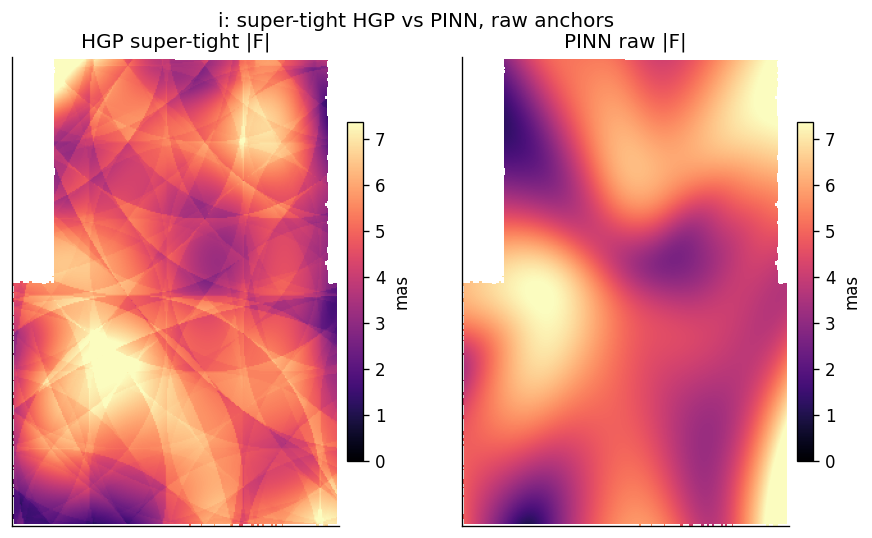

In [19]:
if have_raw_hgp_supertight():
    PLOT_BAND_ST = 'I'
    d = load_resampled_band_supertight(PLOT_BAND_ST)
    m = support_mask_supertight(d)

    panels = {
        'HGP super-tight |F|': amp_mas(d['hgp_dra'], d['hgp_dde']),
        'PINN raw |F|':        amp_mas(d['pinn_dra'], d['pinn_dde']),
    }
    vmax = float(np.nanpercentile(
        np.concatenate([np.where(m, v, np.nan).ravel() for v in panels.values()]),
        98,
    ))
    fig, axes = plt.subplots(1, 2, figsize=(7.5, 4.2), constrained_layout=True)
    for ax, (title, image) in zip(axes, panels.items()):
        show = np.asarray(image, dtype=np.float64).copy()
        show[~m] = np.nan
        im = ax.imshow(show, origin='lower', cmap='magma', vmin=0, vmax=vmax)
        ax.set_title(title)
        ax.set_xticks([]); ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label='mas')
    fig.suptitle(f'{BAND_LABEL[PLOT_BAND_ST]}: super-tight HGP vs PINN, raw anchors', y=1.03)


In [20]:
if have_raw_hgp_supertight():
    anchor_st_rows = []
    with fits.open(HGP_RAW_SUPERTIGHT_FITS, memmap=True) as hgp_st, \
         fits.open(PINN_RAW_FITS, memmap=True) as pinn_raw:
        for band in BANDS:
            key = BAND_KEY[band]
            ra = anchors[f'{key}_ra']
            dec = anchors[f'{key}_dec']
            off = anchors[f'{key}_raw'].astype(np.float64)
            hgp_pred = sample_field_pair(hgp_st, band, ra, dec)
            pinn_pred = sample_field_pair(pinn_raw, band, ra, dec)
            hgp_std = sample_field_pair(hgp_st, band, ra, dec, suffix='_STD')
            hgp_dist = sample_image_at_world(hgp_st['COVERAGE'], ra, dec)
            pinn_dist = sample_image_at_world(pinn_raw['COVERAGE'], ra, dec)
            finite = (
                np.isfinite(off).all(axis=1)
                & np.isfinite(hgp_pred).all(axis=1)
                & np.isfinite(pinn_pred).all(axis=1)
                & np.isfinite(hgp_std).all(axis=1)
                & np.isfinite(hgp_dist) & np.isfinite(pinn_dist)
            )
            finite &= amp_mas(off[:, 0], off[:, 1]) < 200.0
            support = finite & (hgp_dist <= MAX_NEAREST_ANCHOR_ARCSEC) & (pinn_dist <= MAX_NEAREST_ANCHOR_ARCSEC)
            support &= amp_mas(hgp_std[:, 0], hgp_std[:, 1]) <= MAX_HGP_STD_RADIAL_MAS
            for name, mask in [('finite', finite), ('support', support)]:
                if not mask.any():
                    continue
                zero = amp_mas(off[mask, 0], off[mask, 1])
                after_hgp = amp_mas(off[mask, 0] - hgp_pred[mask, 0], off[mask, 1] - hgp_pred[mask, 1])
                after_pinn = amp_mas(off[mask, 0] - pinn_pred[mask, 0], off[mask, 1] - pinn_pred[mask, 1])
                anchor_st_rows.append({
                    'band': BAND_LABEL[band], 'mask': name, 'n': int(mask.sum()),
                    'zero_field_med_mas': float(np.nanmedian(zero)),
                    'hgp_st_after_med_mas': float(np.nanmedian(after_hgp)),
                    'pinn_after_med_mas': float(np.nanmedian(after_pinn)),
                    'hgp_st_delta_med_mas': float(np.nanmedian(zero) - np.nanmedian(after_hgp)),
                    'pinn_delta_med_mas': float(np.nanmedian(zero) - np.nanmedian(after_pinn)),
                })

    anchor_st_df = pd.DataFrame(anchor_st_rows)
    display(anchor_st_df.round(3))

    weighted_st = []
    for mask_name, group in anchor_st_df.groupby('mask'):
        weights = group['n'].to_numpy()
        weighted_st.append({
            'mask': mask_name, 'n_total': int(weights.sum()),
            'hgp_st_delta_source_weighted_mas': float(np.average(group['hgp_st_delta_med_mas'], weights=weights)),
            'pinn_delta_source_weighted_mas': float(np.average(group['pinn_delta_med_mas'], weights=weights)),
        })
    display(pd.DataFrame(weighted_st).round(4))


,band,mask,n,zero_field_med_mas,hgp_st_after_med_mas,pinn_after_med_mas,hgp_st_delta_med_mas,pinn_delta_med_mas
0,u,finite,9582,115.613,115.717,115.476,-0.103,0.137
1,u,support,9582,115.613,115.717,115.476,-0.103,0.137
2,g,finite,47219,48.089,47.877,47.928,0.212,0.161
3,g,support,47219,48.089,47.877,47.928,0.212,0.161
4,r,finite,54787,40.185,40.042,39.984,0.144,0.202
5,r,support,54787,40.185,40.042,39.984,0.144,0.202
6,i,finite,48970,36.232,35.941,36.100,0.290,0.132
7,i,support,48970,36.232,35.941,36.100,0.290,0.132
8,z,finite,35160,37.298,36.888,36.975,0.409,0.322
9,z,support,35160,37.298,36.888,36.975,0.409,0.322


,mask,n_total,hgp_st_delta_source_weighted_mas,pinn_delta_source_weighted_mas
0,finite,491419,0.5147,0.4851
1,support,491419,0.5147,0.4851
